/home/janneke/src/at-gpflow


/tmp/ipykernel_13698/1377722874.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  source["Measurement Time"] = pd.to_datetime(source["Measurement Time"])
/tmp/ipykernel_13698/1377722874.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  source2["Measurement Time"] = pd.to_datetime(source2["Measurement Time"])
/tmp/ipykernel_13698/1377722874.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  target["Measurement Time"] = pd.to_datetime(target["Measurement Time"])
/tmp/ipykernel_13698/1377722874.py:26: FutureWarning: 'H' is deprecated and will be removed in a future ver

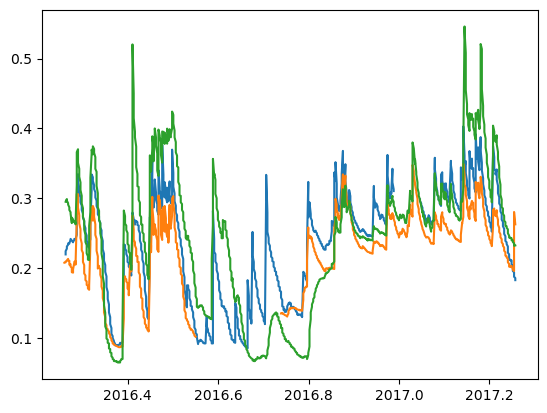

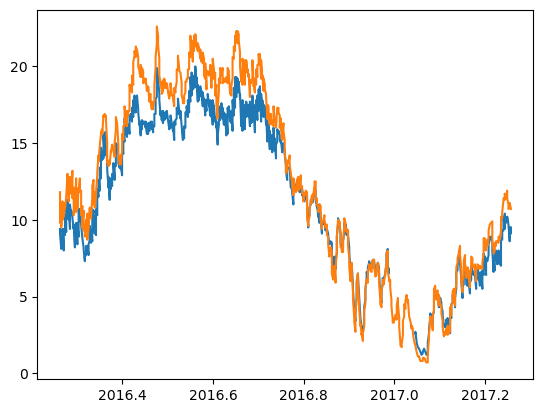

730 729


In [45]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from pathlib import Path
import os
import sys
from pathlib import Path
home = Path.home()
subdir = home / "src" / "at-gpflow"
print(subdir)

sys.path.append(str(subdir))
BASE = os.path.abspath('')

source = pd.read_csv(BASE+"/data/station_data/RM_SM_14_calibrated.csv")
source2 = pd.read_csv(BASE+"/data/station_data/RM_SM_02_calibrated.csv")
target = pd.read_csv(BASE+"/data/station_data/RM_SM_15_calibrated.csv")
source["Measurement Time"] = pd.to_datetime(source["Measurement Time"])
source2["Measurement Time"] = pd.to_datetime(source2["Measurement Time"])
target["Measurement Time"] = pd.to_datetime(target["Measurement Time"])

source.index = source["Measurement Time"]
source2.index = source2["Measurement Time"]
target.index = target["Measurement Time"]

source = source.resample("12H").last()
source2 = source2.resample("12H").last()
target = target.resample("12H").last()

source['decimal_year'] = source['Measurement Time'].dt.year + (source['Measurement Time'].dt.dayofyear - 1) / 365.25
source2['decimal_year'] = source2['Measurement Time'].dt.year + (source2['Measurement Time'].dt.dayofyear - 1) / 365.25
target['decimal_year'] = target['Measurement Time'].dt.year + (target['Measurement Time'].dt.dayofyear - 1) / 365.25
source.index = source["decimal_year"]
source2.index = source2["decimal_year"]
target.index = target["decimal_year"]


plt.plot(source.index, source["5 cm VWC [m3/m3]"])
plt.plot(source2.index, source2["5 cm VWC [m3/m3]"])
plt.plot(target.index, target["5 cm VWC [m3/m3]"])
plt.show()
plt.plot(source.index, source["5 cm Temp [oC]"])
plt.plot(target.index, target["5 cm Temp [oC]"])
plt.show()

print(len(source), len(target))

[[-1.73699404e-01]
 [-1.13137613e-01]
 [-6.67498587e-02]
 [-2.75779771e-02]
 [ 4.76459625e-03]
 [ 3.04067161e-02]
 [ 2.39639725e-02]
 [ 3.04067161e-02]
 [ 9.98594931e-02]
 [ 1.12358416e-01]
 [ 8.10466816e-02]
 [ 8.10466816e-02]
 [ 4.94772375e-02]
 [ 6.84189039e-02]
 [ 8.73605704e-02]
 [ 1.12358416e-01]
 [ 1.06044527e-01]
 [ 1.06044527e-01]
 [ 1.86192259e-01]
 [ 6.67594067e-01]
 [ 1.30632768e+00]
 [ 1.15853114e+00]
 [ 1.05634922e+00]
 [ 9.51074790e-01]
 [ 8.77369802e-01]
 [ 7.86913680e-01]
 [ 7.25192196e-01]
 [ 6.46461868e-01]
 [ 5.76622526e-01]
 [ 5.05365781e-01]
 [ 4.49571621e-01]
 [ 3.75608923e-01]
 [ 3.11696906e-01]
 [ 2.40569015e-01]
 [ 1.73951046e-01]
 [ 8.10466816e-02]
 [ 3.04067161e-02]
 [-2.75779771e-02]
 [-5.37355165e-02]
 [ 3.04067161e-02]
 [ 1.06044527e-01]
 [ 4.15682789e-01]
 [ 9.94498882e-01]
 [ 1.30194661e+00]
 [ 1.24885840e+00]
 [ 1.18133845e+00]
 [ 1.10312354e+00]
 [ 1.03263992e+00]
 [ 9.70403021e-01]
 [ 8.77369802e-01]
 [ 8.17323431e-01]
 [ 7.19909146e-01]
 [ 6.6231101

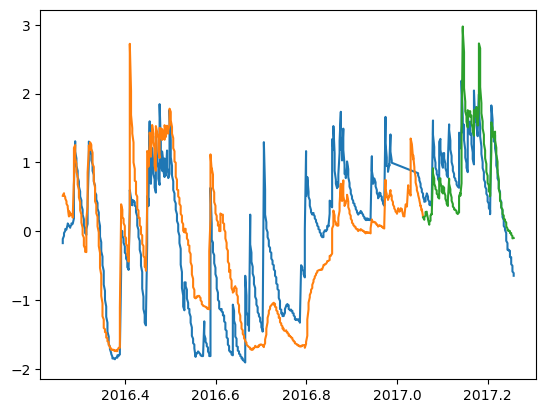

In [46]:
Ax = source.index.to_numpy().reshape(-1, 1)
Bx = target.index.to_numpy().reshape(-1, 1)
Cx = source2.index.to_numpy().reshape(-1, 1)

Ay_nans = source["5 cm VWC [m3/m3]"].to_numpy().reshape(-1, 1) 
Ay = Ay_nans[~np.isnan(Ay_nans)].reshape(-1, 1)
Ay = (Ay - Ay.mean()) / np.std(Ay)
Ax = Ax[~np.isnan(Ay_nans)].reshape(-1, 1)
Ay = (Ay - Ay.mean()) / np.std(Ay)
print(Ay)
By_nans = target["5 cm VWC [m3/m3]"].to_numpy().reshape(-1, 1)
By = By_nans[~np.isnan(By_nans)].reshape(-1, 1)
By = (By - By.mean()) / np.std(By)
Bx = Bx[~np.isnan(By_nans)].reshape(-1, 1)

Xtest = Bx[int(len(Bx)*0.8):] 
ytest = By[int(len(By)*0.8):] 
Bx = Bx[:int(len(Bx)*0.8)] 
By = By[:int(len(By)*0.8)] 

Cy_nans = source2["5 cm VWC [m3/m3]"].to_numpy().reshape(-1, 1)
Cy = Cy_nans[~np.isnan(Cy_nans)].reshape(-1, 1)
Cy = (Cy - Cy.mean()) / np.std(Cy)
Cx = Cx[~np.isnan(Cy_nans)].reshape(-1, 1)

X = np.vstack((np.hstack((Ax, np.zeros_like(Ax))), np.hstack((Bx, np.ones_like(Bx)))))
y = np.vstack((np.hstack((Ay, np.zeros_like(Ay))), np.hstack((By, np.ones_like(By)))))
plt.plot(Ax, Ay)
plt.plot(Bx, By)
plt.plot(Xtest, ytest)

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤══════════╤═════════╤═════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape    │ dtype   │ value           │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪══════════╪═════════╪═════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 1.0             │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼─────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 1.0             │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼────

2026-08-13 17:03:29.459341: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.


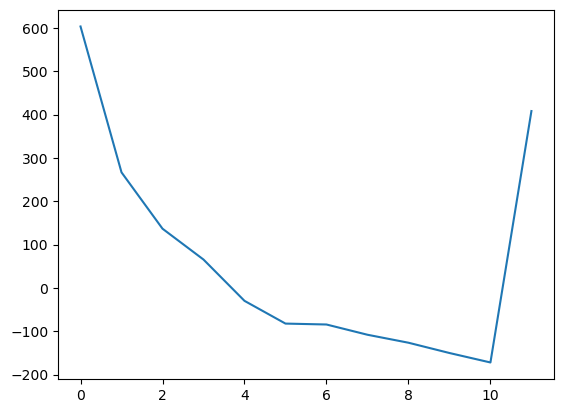

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤══════════╤═════════╤═════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape    │ dtype   │ value                   │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪══════════╪═════════╪═════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 1.71349                 │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼─────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 0.08100565698163908     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─

In [63]:
from atmodel import SparseCMOGP, ConditionalMOGP
from atlikelihood import TransferLikelihood
import gpflow as gpf

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
nIVS = 200
ivs = np.linspace(min(X[:,0]), max(X[:,0]), nIVS).reshape(-1, 1)
iv_ind = np.concatenate((np.ones((int(nIVS/2),1 )), np.zeros((int(nIVS/2), 1))))  # I guess the IPs for the target don't matter here, but this makes the comparison fair.
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))
kern = k * coreg
#m = ConditionalMOGP((X, y), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
m = SparseCMOGP((X, y), exact_target=False, kernel=kern, jitter=1e-6, inducing_variable=ivs, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#gpf.set_trainable(m.kernel.kernels[0].variance, True)
#gpf.set_trainable(m.likelihood.source.variance, False)

gpf.utilities.print_summary(m)
optimize(m)
gpf.utilities.print_summary(m)

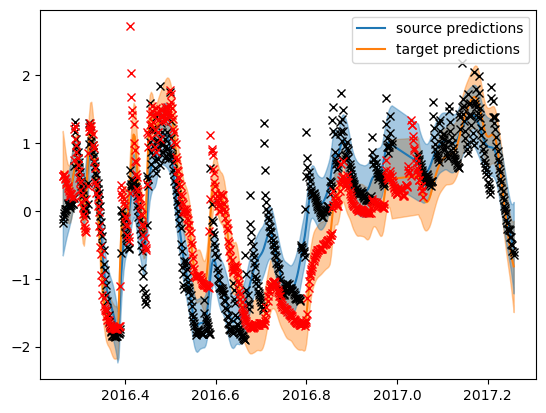

0.17458027776204205

In [64]:
from sklearn.metrics import mean_squared_error
Xtst = Xtest.reshape(-1, 1)
Xall = Ax
Xplot = np.hstack((Xall, np.zeros_like(Xall)))
Xplot2 = np.hstack((Xall, np.ones_like(Xall)))
Xtest_stack = np.hstack((Xtst, np.ones_like(Xtst)))
fmean, fvar = m.predict_f(Xplot)
fmean2, fvar2 = m.predict_f(Xplot2)
fmean_tst, fvar_tst = m.predict_f(Xtest_stack)
plt.plot(Xall, fmean, color="C0", label="source predictions")
plt.plot(Xall, fmean2, color="C1", label="target predictions")
plt.plot(Ax, Ay, "kx")
plt.plot(Bx, By, "rx")
plt.fill_between(
    Xall[:, 0],
    (fmean2 - 2 * np.sqrt(fvar))[:, 0],
    (fmean2 + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C0",
    alpha=0.4,
)
plt.legend()
#plt.scatter(m.inducing_variable.Z[:,0], np.ones_like(ivs[:,0])*0, marker="x", c=ivs[:,1], zorder=100, s=100, alpha=0.6)
plt.show()
ours_mse = mean_squared_error(ytest, fmean_tst)
ours_mse